# Offline vs cloud LLM tutoring — teaching quality, latency and cost

Everything below is computed from **one dataset**:
`offline_eval/export/ai_tutor_geography_dataset.xlsx`, also present as CSVs in
the same folder. Nothing is a restated figure, and nothing reaches outside that
export — so anyone holding the workbook can re-run this notebook and get the
same tables and charts.

## The data

Five tutoring systems over the same 34 geography scenarios, same engine, same
simulated students. Two run on one local GPU; three through cloud APIs.

| sheet | rows | one row is |
|---|---:|---|
| `transcripts` | 2,882 | one message, in order, with its text |
| `sessions` | 170 | one tutoring session |
| `tutor_responses` | 1,526 | one tutor response: tokens, tools, verdict |
| `grades_long` | 1,353 | one graded session × dimension |
| `concurrency` | 10 | one load level on the GPU sweep |

A **tutor response** is one message from the tutor, not an exchange: a session
with 7 tutor responses also holds 6–7 student messages. `session_id` joins
every sheet.

**Geography only.** Two maths lessons hold fewer bank questions than a session
consumes, so sessions there end on the turn cap rather than on the tutor's
behaviour — a content defect that would read as a model difference.

## One caution before the numbers

`assertions_passed` in `sessions` records only that the session ran, tools
fired and grading resolved. It is **not** a measure of teaching. The quality
signal is `session_passes` in `grades_long`, from human grading, and nowhere
else.

In [1]:
import collections, pathlib, sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = pathlib.Path.cwd()
if ROOT.name == "offline_eval":
    ROOT = ROOT.parent
EXPORT = ROOT / "offline_eval" / "export"
sys.path.insert(0, str(ROOT))

if not (EXPORT / "sessions.csv").exists():
    raise SystemExit(f"No export at {EXPORT}. Build it with:\n"
                     f"    python offline_eval/export_dataset.py")

# CSVs rather than the workbook: same content, and it keeps the notebook
# runnable without an Excel engine installed.
sessions   = pd.read_csv(EXPORT / "sessions.csv")
transcripts= pd.read_csv(EXPORT / "transcripts.csv")
responses  = pd.read_csv(EXPORT / "tutor_responses.csv")
grades     = pd.read_csv(EXPORT / "grades_long.csv")
concurrency= pd.read_csv(EXPORT / "concurrency.csv")

LOCAL, CLOUD, GREY = "#1b6ca8", "#c0562f", "#777777"
SHADE = {"qwen3-4b-jetson": "#7fb3d5", "qwen3.8-27b-instruct": "#15476b",
         "gemini-3.5-flash": "#f0b48a", "gpt-5.4-mini": "#d97742",
         "claude-opus-4-7": "#8c2f11"}
ORDER = ["qwen3-4b-jetson", "qwen3.8-27b-instruct",
         "gemini-3.5-flash", "gpt-5.4-mini", "claude-opus-4-7"]
IS_LOCAL = lambda a: a.startswith("qwen")

print(f"loaded from {EXPORT}")
for nm, df in [("sessions", sessions), ("transcripts", transcripts),
               ("tutor_responses", responses), ("grades_long", grades),
               ("concurrency", concurrency)]:
    print(f"  {nm:<18}{len(df):>6} rows")

loaded from /Users/edwardamoah/Documents/GitHub/ai-tutor/offline_eval/export
  sessions             170 rows
  transcripts         2882 rows
  tutor_responses     1526 rows
  grades_long         1353 rows
  concurrency           10 rows


## 1. Check the run before trusting it

A **placeholder** means a tutor response fell back to canned text after a
failed call; a **retry** means a call had to be reissued. Any non-zero count
here would mean the latency and quality figures describe a degraded system
rather than the real one, so this is the first thing to look at.

In [2]:
check = (responses.groupby(["tier", "arm"])
         .agg(sessions=("session_id", "nunique"),
              tutor_responses=("session_id", "size"),
              placeholders=("placeholder", "sum"),
              retries=("retries", "sum"))
         .reset_index())
check

,tier,arm,sessions,tutor_responses,placeholders,retries
0,cloud,claude-opus-4-7,34,314,0,0
1,cloud,gemini-3.5-flash,34,310,0,0
2,cloud,gpt-5.4-mini,34,295,0,0
3,on-device,qwen3-4b-jetson,34,313,0,9
4,on-device,qwen3.8-27b-instruct,34,294,0,0


## 2. Latency — what a student waits for one reply

In [3]:
# Tutor messages only. The student side is the simulator, not the system under
# test, so its sub-second replies would dilute the number a real student waits.
tut = transcripts[(transcripts.role == "tutor") & transcripts.latency_seconds.notna()]
lat = (tut.groupby("arm")["latency_seconds"]
       .agg(responses="size", p50="median",
            p95=lambda x: x.quantile(0.95), max="max")
       .round(2).reindex(ORDER))
lat

,responses,p50,p95,max
arm,,,,
qwen3-4b-jetson,313,5.10,8.55,45.26
qwen3.8-27b-instruct,294,19.62,26.36,30.26
gemini-3.5-flash,310,10.55,17.16,35.68
gpt-5.4-mini,295,1.65,3.13,7.83
claude-opus-4-7,314,4.27,6.34,12.65


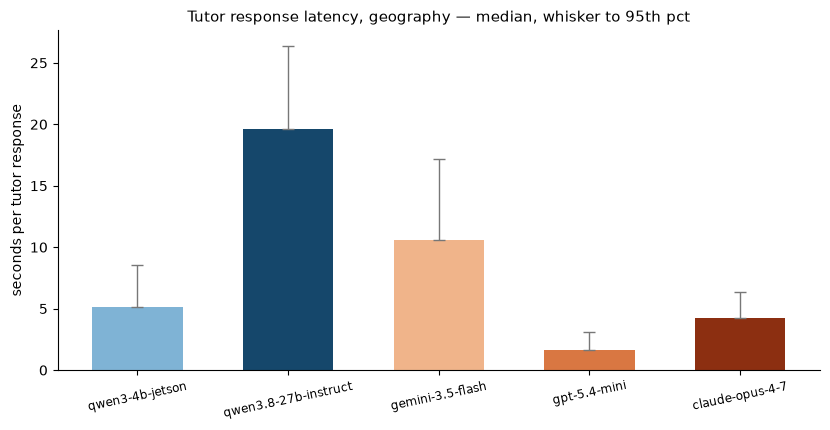

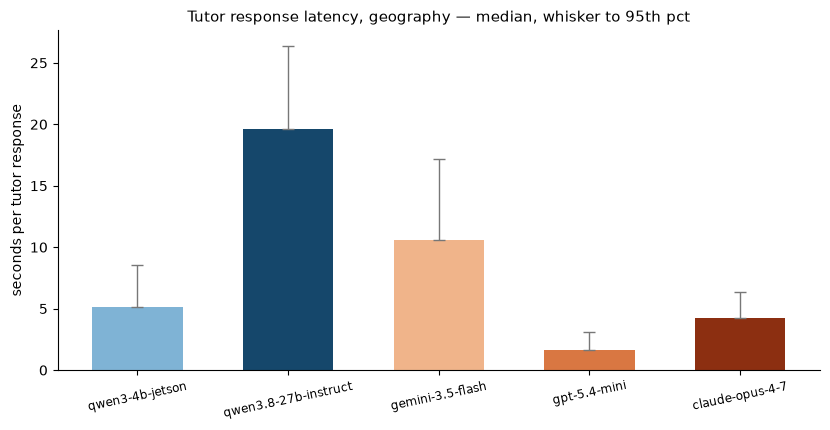

In [4]:
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(range(len(lat)), lat.p50, 0.6,
       yerr=[[0]*len(lat), (lat.p95 - lat.p50).clip(lower=0)],
       color=[SHADE[a] for a in lat.index], capsize=4,
       error_kw={"ecolor": GREY, "lw": 1})
ax.set_xticks(range(len(lat))); ax.set_xticklabels(lat.index, fontsize=8.5, rotation=12)
ax.set_ylabel("seconds per tutor response")
ax.set_title("Tutor response latency, geography — median, whisker to 95th pct",
             fontsize=11)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.tight_layout(); fig.savefig(ROOT/"offline_eval/figures/fig1_latency.png", dpi=200)
fig

**The on-device 4B is not the slow option.** At 5.09s per response it beats
Gemini Flash (10.55s) and sits close to Opus (4.27s). The slowest cloud arm is
slower than the faster on-device one — the opposite of the usual assumption
about local inference.

## 3. Cost

Cloud tutoring is metered per token; on-device tutoring is not metered at all.
The two are reported in the units they actually have rather than forced onto a
common denominator.

In [5]:
# Published list prices, USD per million tokens.
PRICE_IN  = {"claude-opus-4-7": 5.00, "gemini-3.5-flash": 0.30, "gpt-5.4-mini": 0.25}
PRICE_OUT = {"claude-opus-4-7": 25.00, "gemini-3.5-flash": 2.50, "gpt-5.4-mini": 2.00}
CACHE_READ, CACHE_WRITE = 0.10, 1.25
CHARS_PER_TOKEN, CALL1_OUT = 4.0, 25

pd.DataFrame([{"model": m, "input": PRICE_IN[m], "output": PRICE_OUT[m],
               "cache read": round(PRICE_IN[m]*CACHE_READ, 3),
               "cache write": round(PRICE_IN[m]*CACHE_WRITE, 3)}
              for m in PRICE_IN]).set_index("model")

,input,output,cache read,cache write
model,,,,
claude-opus-4-7,5.00,25.0,0.500,6.250
gemini-3.5-flash,0.30,2.5,0.030,0.375
gpt-5.4-mini,0.25,2.0,0.025,0.312


In [6]:
# Computed here rather than shipped in the export. The measured quantity is
# TOKENS; the dollar figure needs list prices that move, cache multipliers, and
# an ESTIMATE of the output tokens the tracer never recorded. Keeping the
# derivation visible is more honest than presenting a cost column as data.
cl = responses[responses.arm.isin(PRICE_IN)].copy()
cl["tokens_output_est"] = cl.reply_characters/CHARS_PER_TOKEN + CALL1_OUT
cost = (cl.groupby("arm").agg(
            fresh=("tokens_input_fresh", "sum"),
            cached=("tokens_input_cached", "sum"),
            written=("tokens_cache_write", "sum"),
            out=("tokens_output_est", "sum"),
            sessions=("session_id", "nunique")).reset_index())
pi, po = cost.arm.map(PRICE_IN), cost.arm.map(PRICE_OUT)
# The three input buckets are DISJOINT: a provider's input_tokens excludes
# cached tokens, so the prompt's true size is their sum.
cost["billed"]   = (cost.fresh*pi + cost.cached*pi*CACHE_READ
                    + cost.written*pi*CACHE_WRITE + cost.out*po) / 1e6
cost["uncached"] = ((cost.fresh + cost.cached + cost.written)*pi + cost.out*po) / 1e6
cost["per_session"] = cost.billed / cost.sessions
show = cost.assign(**{"billed $": cost.billed.round(2),
                      "per session $": cost.per_session.round(4),
                      "if uncached $": cost.uncached.round(2),
                      "saved": (100*(1-cost.billed/cost.uncached)).round(0)}) \
           [["arm","fresh","cached","written","out","billed $","per session $",
             "if uncached $","saved"]]
display(show)
# Totalled from unrounded values: summing a rounded column accumulates error.
print(f"total billed ${cost.billed.sum():.2f}   uncached ${cost.uncached.sum():.2f}"
      f"   caching saved ${cost.uncached.sum()-cost.billed.sum():.2f}")

,arm,fresh,cached,written,out,billed $,per session $,if uncached $,saved
0,claude-opus-4-7,1504857,4124127,415837,41884.50,13.23,0.3892,31.27,58.0
1,gemini-3.5-flash,5557243,244212,0,34996.50,1.76,0.0518,1.83,4.0
2,gpt-5.4-mini,3613357,2209408,0,31253.75,1.02,0.0300,1.52,33.0


total billed $16.02   uncached $34.62   caching saved $18.60


**Per session is the number that scales.** A school pays it again for every
session, every year; it does not fall with volume.

Gemini's caching barely engages against Opus's. On a workload that re-sends the
same static prefix on every tutor response, cache reads should dominate after
the first response of a session. It costs little at Flash prices, but the same
behaviour on a more expensive model would re-bill the whole prefix every time.

### On-device: capital, not a per-token price

| item | cost |
|---|---:|
| NVIDIA RTX 3090, 24 GB | **$2,500**, one-off |

Both on-device models run on this one card, so the hardware cost is the same
whichever is deployed, and there is no per-token charge at all.

That is the whole difference. A metered service is paid for again with every
session; a bought card is paid for once. Going further — cost per student per
year, or a break-even against teacher time — needs assumptions about usage
intensity, card lifetime and wage levels that this study did not measure, and
those assumptions would drive the answer more than anything measured here.

## 4. Teaching quality — the central result

169 sessions graded by hand against eight pedagogical dimensions. A session
passes only if **every applicable dimension** sits at its desideratum:
all-or-nothing. `n/a` is excluded from scoring rather than counted as a
failure, and an incomplete grading is excluded entirely — an unanswered
dimension is not a "no", and scoring it as one would invent failures the grader
never recorded.

In [7]:
comp = grades[grades.grading_complete].copy()
print(f"{grades.session_id.nunique()} sessions in the grade file, "
      f"{comp.session_id.nunique()} completely graded, "
      f"{int(comp.peeked.sum()/8)} peeked")

per_session = comp.groupby(["arm", "session_id"]).session_passes.first()
passrate = (per_session.groupby("arm").agg(graded="size", passed="sum")
            .assign(pass_rate=lambda d: (100*d.passed/d.graded).round(0))
            .reindex(ORDER))
passrate

170 sessions in the grade file, 169 completely graded, 0 peeked


,graded,passed,pass_rate
arm,,,
qwen3-4b-jetson,34,23,68.0
qwen3.8-27b-instruct,34,33,97.0
gemini-3.5-flash,34,24,71.0
gpt-5.4-mini,33,29,88.0
claude-opus-4-7,34,34,100.0


'Peeked' would mean the automated grade was revealed before grading finished —
such a session measures anchoring rather than independent judgement. None here.

In [8]:
# All eight dimensions, in the order pedagogy.py asks them, including the four
# every arm passes. Hiding those would report only where models differ and lose
# the equally useful result that none failed to spot a mistake or sound human.
DIM_ORDER = ["mistake_identification", "mistake_location", "revealing_answer",
             "providing_guidance", "actionability", "coherence",
             "tutor_tone", "human_likeness"]
scorable = comp[comp.at_desideratum.notna()]
fails = (scorable.groupby(["dimension", "arm"]).at_desideratum
         .apply(lambda x: 100*(~x.astype(bool)).mean())
         .unstack().reindex(index=DIM_ORDER, columns=ORDER).round(0))
fails.insert(0, "want", [comp[comp.dimension == d].desideratum.iloc[0] for d in DIM_ORDER])
fails

arm,want,qwen3-4b-jetson,qwen3.8-27b-instruct,gemini-3.5-flash,gpt-5.4-mini,claude-opus-4-7
dimension,,,,,,
mistake_identification,yes,0.0,0.0,0.0,0.0,0.0
mistake_location,yes,0.0,0.0,0.0,0.0,0.0
revealing_answer,no,32.0,0.0,3.0,9.0,0.0
providing_guidance,yes,0.0,0.0,24.0,3.0,0.0
actionability,yes,15.0,0.0,0.0,0.0,0.0
coherence,yes,0.0,3.0,6.0,0.0,0.0
tutor_tone,encouraging,0.0,0.0,0.0,0.0,0.0
human_likeness,yes,0.0,0.0,0.0,0.0,0.0


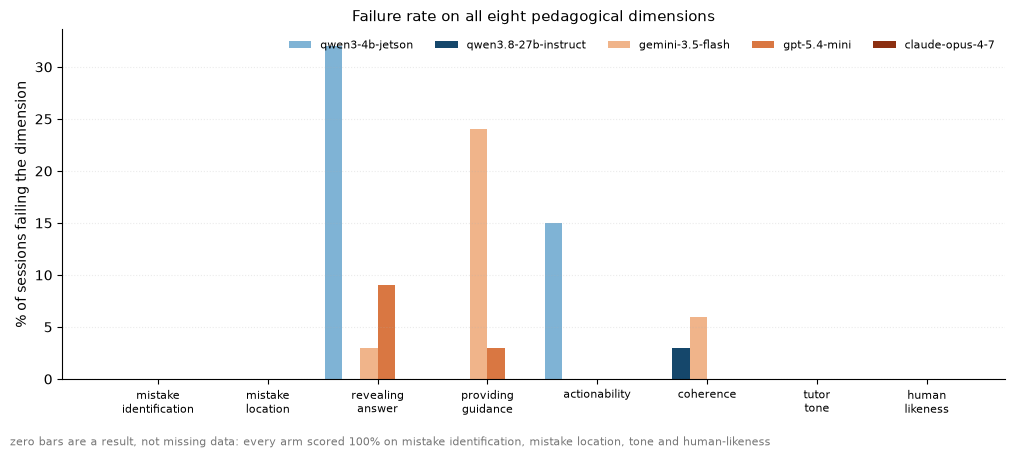

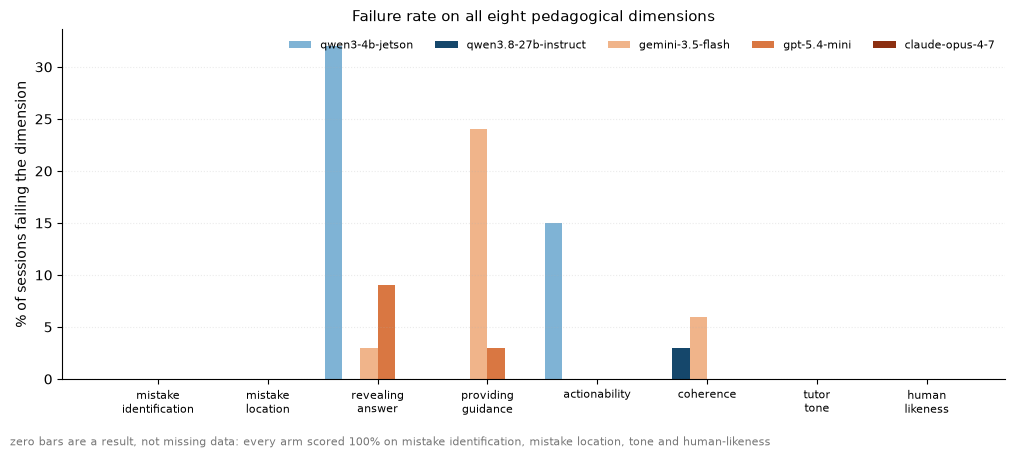

In [9]:
fig, ax = plt.subplots(figsize=(10.2, 4.6))
plot = fails.drop(columns="want")
w = 0.8/len(plot.columns)
for i, arm in enumerate(plot.columns):
    ax.bar([j + i*w - 0.4 for j in range(len(plot))], plot[arm], w,
           label=arm, color=SHADE[arm])
ax.set_xticks(range(len(plot)))
ax.set_xticklabels([d.replace("_", "\n") for d in plot.index], fontsize=8)
ax.set_ylabel("% of sessions failing the dimension")
ax.set_title("Failure rate on all eight pedagogical dimensions", fontsize=11)
ax.legend(fontsize=8, frameon=False, ncol=5)
ax.grid(axis="y", alpha=0.25, ls=":")
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.text(0.01, 0.02, "zero bars are a result, not missing data: every arm scored "
         "100% on mistake identification, mistake location, tone and human-likeness",
         fontsize=8, color=GREY)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(ROOT/"offline_eval/figures/fig4_dimensions.png", dpi=200)
fig

A single failure rate hides *how* a dimension failed. `to_some_extent` is a
tutor being vague; `no` is a tutor being wrong; `yes_correct` on
`revealing_answer` is a tutor handing over the answer. Different problems,
different fixes — so the verdicts are shown as recorded.

In [10]:
off = comp[(comp.at_desideratum == False)]
(off.groupby(["dimension", "arm", "verdict"]).size()
    .rename("sessions").reset_index()
    .sort_values(["dimension", "sessions"], ascending=[True, False])
    .reset_index(drop=True))

,dimension,arm,verdict,sessions
0,actionability,qwen3-4b-jetson,to_some_extent,5
1,coherence,gemini-3.5-flash,to_some_extent,2
2,coherence,qwen3.8-27b-instruct,to_some_extent,1
3,providing_guidance,gemini-3.5-flash,to_some_extent,8
4,providing_guidance,gpt-5.4-mini,to_some_extent,1
5,revealing_answer,qwen3-4b-jetson,yes_correct,11
6,revealing_answer,gpt-5.4-mini,yes_correct,3
7,revealing_answer,gemini-3.5-flash,yes_correct,1


**Every arm scored 100% on four of the eight dimensions** — mistake
identification, mistake location, tutor tone and human-likeness. No model
struggled to spot an error, locate it, stay encouraging, or sound human.

All separation is in the other four, and each tier fails differently:

- **qwen3-4B** hands over the answer in 32% of sessions (11 of 34, every one of
  them the *correct* answer) and is vague about the next step in 15%. It knows
  the answer and tells the student — a failure of pedagogical restraint, not of
  capability.
- **Gemini 3.5 Flash** gives only partial guidance in 24% of sessions — the
  largest single weakness of any arm, and why a cloud model finishes below an
  on-device one.
- **qwen3.8-27B** fails once, on coherence, across 34 sessions.
- **Opus 4.7** does not fail on any dimension.

Because the gap is a few specific behaviours rather than general competence, it
is the kind of thing prompt and policy can address — the practically important
finding for anyone deploying the smaller model.

### Reading a session

Any verdict above can be traced to the conversation behind it. `session_id`
joins the grades to the transcript.

In [11]:
# A session the 4B failed on revealing_answer — the transcript shows why.
bad = comp[(comp.arm == "qwen3-4b-jetson") & (comp.dimension == "revealing_answer")
           & (comp.at_desideratum == False)].session_id.iloc[0]
conv = transcripts[transcripts.session_id == bad].sort_values("message_index")
print(f"session {bad} — {sessions[sessions.session_id==bad].scenario_id.iloc[0]}\n")
for _, m in conv.head(6).iterrows():
    print(f"  {m.role:<8} {str(m.message)[:96]}")

session 1213 — average_geo_scale_001

  tutor    Hello! Today we’re exploring the difference between large and small scale maps.  

To warm up, h
  student  D
  tutor    Got it — that's right. Here's the next one:

Which of the following best defines a large scale m
  student  B
  tutor    Correct — nice work. Try this one:

If you measured 6 cm between two towns on a map with a scale
  student  B


## 5. Concurrency — how many students one card serves

Each level of the sweep fires N simultaneous whole tutor responses (the short
tool-selecting call, then the full reply) and records how latency degrades.
Requests beyond the server's slot count queue rather than fail, so N can exceed
the slots.

In [12]:
display(concurrency)

BUDGET = 30.0    # seconds a student will wait for one tutor response
cap = pd.DataFrame({
    f"max N, median <= {BUDGET:.0f}s":
        concurrency[concurrency.response_seconds_p50 <= BUDGET]
            .groupby("model").concurrent_requests.max(),
    f"max N, 95th pct <= {BUDGET:.0f}s":
        concurrency[concurrency.response_seconds_p95 <= BUDGET]
            .groupby("model").concurrent_requests.max(),
})
cap

,model,parallel_slots,concurrent_requests,response_seconds_p50,response_seconds_p95
0,qwen3-4b-ctx8k,24,1,2.6,2.5
1,qwen3-4b-ctx8k,24,32,20.0,28.6
2,qwen3-4b-ctx8k,24,48,28.8,36.3
3,qwen3-4b-ctx8k,24,64,39.4,51.1
4,qwen3-4b-ctx8k,24,80,44.0,59.9
5,qwen3.8-27b-instruct,4,1,8.9,8.8
6,qwen3.8-27b-instruct,4,4,22.6,28.3
7,qwen3.8-27b-instruct,4,6,31.5,42.8
8,qwen3.8-27b-instruct,4,8,39.0,52.6
9,qwen3.8-27b-instruct,4,12,55.6,77.6


,"max N, median <= 30s","max N, 95th pct <= 30s"
model,,
qwen3-4b-ctx8k,48,32
qwen3.8-27b-instruct,4,4


**This is the deployment constraint.** The 27B teaches nearly as well as a
frontier model but serves a handful of students at once; the 4B serves an order
of magnitude more and hands over the answer far too often. Fixing the 4B's
answer-revealing behaviour is worth more than any model swap available here —
it is the only change that would give a full class frontier-adjacent tutoring
on one card.

## 6. Summary

| | |
|---|---|
| **Quality** | the on-device 27B reaches 97% against Opus's 100%, and beats both cheaper cloud models |
| **Failure modes** | all separation sits in 4 of 8 dimensions; every arm is perfect on the other 4 |
| **Latency** | the on-device 4B beats two of three cloud arms |
| **Cost** | cloud is metered per session and repeats; the card is $2,500 once |
| **Capacity** | the 27B serves ~4 concurrent students, the 4B ~48 |

### What this does not establish

- **One subject.** All of this is geography. Whether the ranking holds on a
  more reasoning-heavy subject is untested here.
- **Tutoring quality, not learning.** The grades record whether an expert
  judged the tutoring sound. Whether students learn more would need a
  controlled trial, which this is not.
- **No total cost of ownership.** The cost section reports published token
  prices, what this run consumed, and the price of the card. It stops short of
  cost per student per year, which would need assumptions about usage, card
  lifetime and staff time that were never measured.
- **One grader.** 169 sessions, no second rater, so no inter-rater reliability
  figure.
- **Simulated students.** The student side is an LLM following a persona, not
  a child. Latency figures exclude it for that reason, but the tutor's
  behaviour was still elicited by a simulation.